# KDEllipsPy: Synthetic Simulation Example for Google Colab

This notebook demonstrates how to run a synthetic earthquake simulation using the Axitra forward engine with an elliptical slip patch distribution.

### 1. Installation

We clone the repository and install the dependencies. **Crucial:** We must ensure NumPy < 2.0.0 and SciPy < 1.14.0 are used to maintain compatibility with the Python 3.12 environment in Colab.

In [1]:
# # 1. Clone the repository
# !git clone https://github.com/alexvillarroel/KDEllipsPy.git
# %cd KDEllipsPy

# # 2. Uninstall conflicting versions
# !pip uninstall -y numpy scipy

# # 3. Install stable dependencies and build tools
# !pip install "numpy>=1.26.4,<2.0.0" "scipy<1.14.0" pyproj obspy neighpy pymc arviz --quiet

# # 4. Install KDEllipsPy (this will compile the Axitra Fortran binaries)
# !pip install -e .

**Note:** If Colab asks you to "Restart Session" after installation, please do so before continuing.

### 2. Imports and Configuration

We load the configuration from an `input.ctl` file. This file contains the velocity model, station locations, and fault plane parameters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from kdellipspy import ConfigParser, AxitraForwardModel, EllipseDiagnostics
from pathlib import Path

# Use an existing example configuration
input_file = "inversions/calama2020/input.ctl"
cfg = ConfigParser(input_file)

print(f"Loaded configuration: {cfg.source_position.event_name}")
print(f"Stations: {len(cfg.stations.stations)}")

Loaded configuration: Calama 2020 Intraplate
Stations: 8


### 3. Define the Elliptical Slip Model

The elliptical model is defined by 7 parameters:
1. `a1`: Semi-axis 1 (km)
2. `a2`: Semi-axis 2 (km)
3. `theta`: Rotation angle (fraction of $\pi$)
4. `np`: Position fraction [0, 1] relative to center
5. `tp`: Position angle (fraction of $2\pi$)
6. `dmax`: Maximum slip (meters)
7. `vr`: Rupture velocity (km/s)

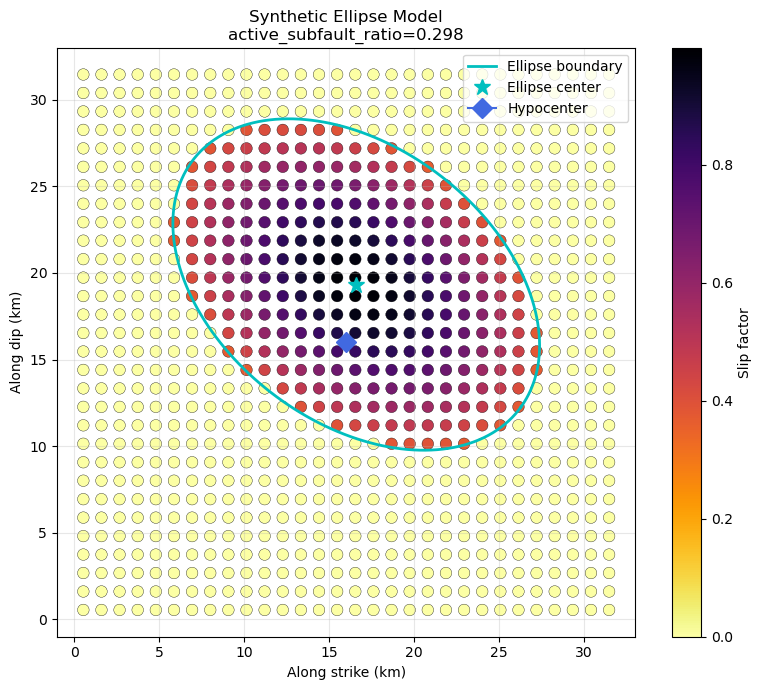

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Synthetic Ellipse Model\nactive_subfault_ratio=0.298'}, xlabel='Along strike (km)', ylabel='Along dip (km)'>)

In [3]:
# Model parameters: [a1_km, a2_km, theta_pi, np, tp_2pi, dmax_m, vr_kms]
model_params = np.array([12.0, 8.0, 0.2, 0.4, 0.3, 3.5, 2.8])

# Visualize the ellipse on the fault plane before running simulation
diag = EllipseDiagnostics(cfg)
res = diag.evaluate(model_params)
diag.plot(res, title="Synthetic Ellipse Model")

### 4. Run Forward Simulation

Now we run the Axitra engine to compute Green's functions and convolve them with the source time function.

In [4]:
print("Initializing Forward Model...")
fm = AxitraForwardModel(input_file)

print("1. Building geometry...")
geom = fm.build_geometry_with_ellipse_slip(model_params)

print("2. Computing Green's Functions (Axitra)... ")
ap = fm.build_axitra(geom)
ap = fm.green(ap, quiet=True)

print("3. Convolving with source function...")
# source_type=1 (Ricker wavelet), unit=1 (Displacement)
time, sx, sy, sz = fm.conv(ap, geom, source_type=1, unit=1, quiet=True)

print("Done!")
print(f"Synthetics generated for {sx.shape[0]} stations.")

Initializing Forward Model...
1. Building geometry...
2. Computing Green's Functions (Axitra)... 
3. Convolving with source function...
Done!
Synthetics generated for 8 stations.


### 5. Plot Synthetic Seismograms

We plot the North, East, and Vertical components for the first 3 stations.

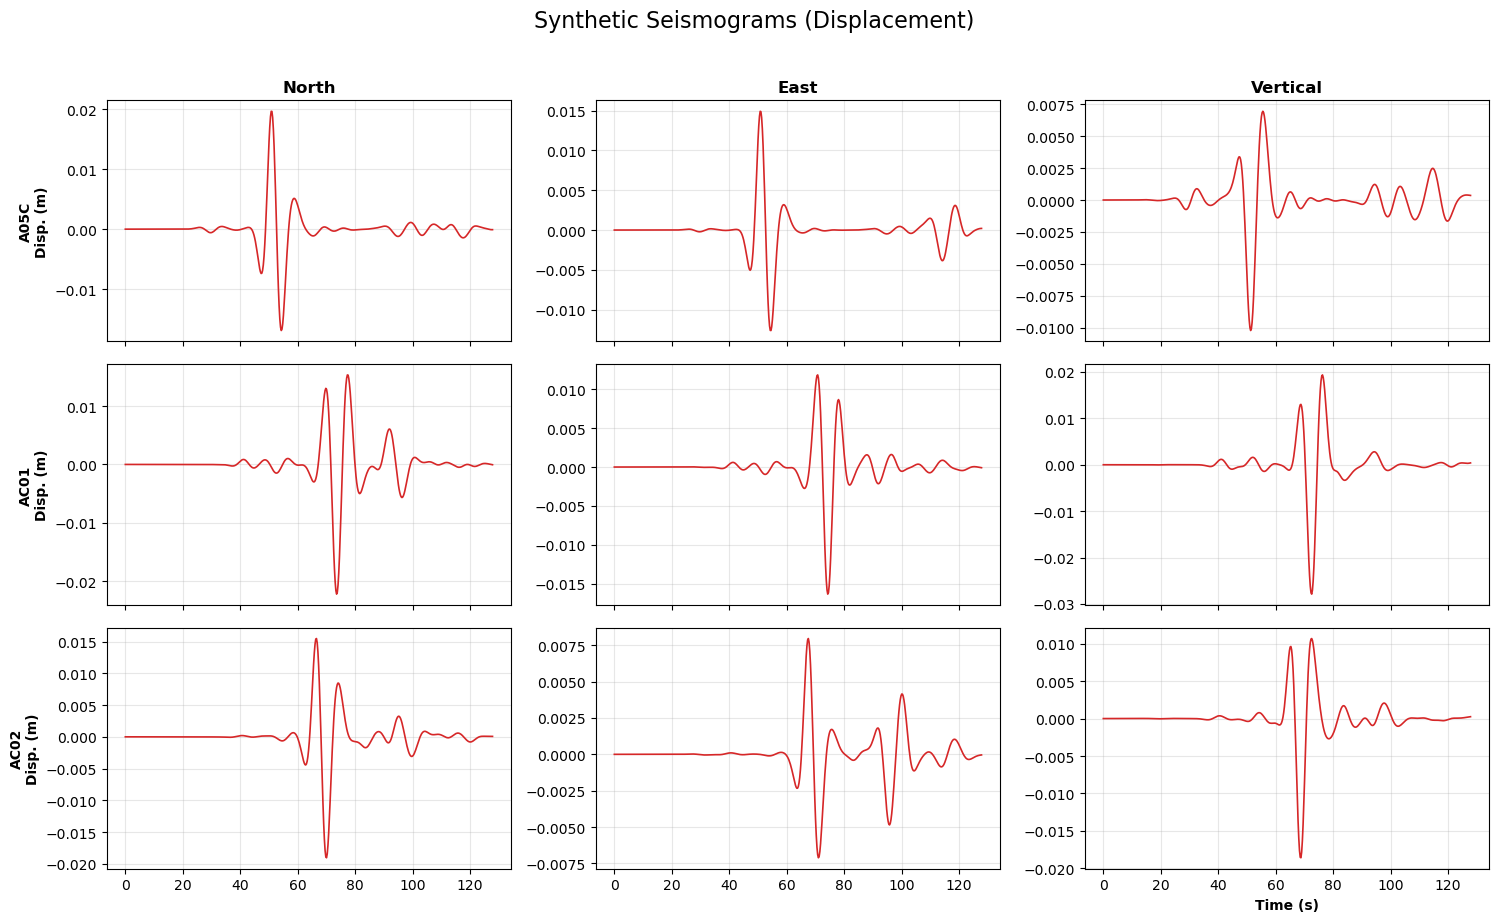

In [6]:
n_to_plot = min(3, sx.shape[0])
fig, axes = plt.subplots(n_to_plot, 3, figsize=(15, 3 * n_to_plot), sharex=True)

comps = ["North", "East", "Vertical"]
data_list = [sx, sy, sz]

for i in range(n_to_plot):
    sta_name = cfg.stations.stations[i].name
    for j in range(3):
        ax = axes[i, j] if n_to_plot > 1 else axes[j]
        ax.plot(time, data_list[j][i, :], color="tab:red", lw=1.2)
        if i == 0: ax.set_title(comps[j], fontweight="bold")
        if j == 0: ax.set_ylabel(f"{sta_name}\nDisp. (m)", fontweight="bold")
        ax.grid(True, alpha=0.3)

plt.xlabel("Time (s)", fontweight="bold")
plt.suptitle("Synthetic Seismograms (Displacement)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()